2 runs, ~6 minutes. The key thing this experiment answers is whether Exp3's failure was due to the missing temporal embedding or the Legendre component itself. The decision guide in the summary covers all three possible outcomes so you know exactly what to do after results come in.

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os

project_path = '/content/drive/MyDrive/Dist-Abl-PRL-All-Exs-ETTH1'
os.chdir(project_path)

print("Current Directory:", os.getcwd())

Current Directory: /content/drive/MyDrive/Dist-Abl-PRL-All-Exs-ETTH1


In [3]:
!ls -la experiments/E-96-3b-Label-Temporal-Controlled/exp3b.sh

-rw------- 1 root root 9272 Apr  5 12:52 experiments/E-96-3b-Label-Temporal-Controlled/exp3b.sh


In [4]:
import os

# Set your Informer data directory
informer_path = f'{project_path}/Informer2020-original'
data_dir = f'{informer_path}/data/ETT'
os.makedirs(data_dir, exist_ok=True)

# File path
data_file = f'{data_dir}/ETTh1.csv'

# Download ETTh1 dataset
if not os.path.exists(data_file):
    print("Downloading ETTh1.csv...")
    os.system(
        f'wget -q "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv" '
        f'-O "{data_file}"'
    )

# Verify
if os.path.exists(data_file):
    print(f"✅ Download successful: {data_file}")
else:
    print("❌ Download failed.")

✅ Download successful: /content/drive/MyDrive/Dist-Abl-PRL-All-Exs-ETTH1/Informer2020-original/data/ETT/ETTh1.csv


In [5]:
# Fix np.Inf -> np.inf in tools.py (removed in NumPy 2.0)
tools_path = f'{project_path}/Informer2020-original/utils/tools.py'

with open(tools_path, 'r') as f:
    content = f.read()

content_fixed = content.replace('np.Inf', 'np.inf')

with open(tools_path, 'w') as f:
    f.write(content_fixed)

print("✅ Fixed np.Inf -> np.inf in utils/tools.py")

✅ Fixed np.Inf -> np.inf in utils/tools.py


In [8]:
!bash experiments/E-96-3b-Label-Temporal-Controlled/exp3b.sh

Experiment 3b — Phase 1: Label + Temporal (Controlled)
Formula   : X'_i = X_i + T_i + P_i
Value     : TokenEmbedding (semantic content)
Temporal  : TimeFeatureEmbedding (RESTORED vs Exp3)
Position  : Legendre polynomials (replaces sinusoidal PE)
No distance operator, no alpha, no ordering signal

Key fix   : PYTHONPATH includes models/ for legendre import
Seed      : 2021 | Pred lengths: 96, 192 | Total runs: 2
Start: Sun Apr  5 12:58:39 PM UTC 2026

Copying experiment files...
Files copied successfully.

------------------------------------------------------------
RUN 1/2: exp3b_ph1_ETTh1_leg_temporal_pred96_seed2021
pred_len=96 | seed=2021 | config=legendre+temporal
Start: Sun Apr  5 12:58:40 PM UTC 2026
Args in experiment:
Namespace(model='informer', data='ETTh1', root_path='./data/ETT/', data_path='ETTh1.csv', features='M', target='OT', freq='h', checkpoints='./checkpoints/', seq_len=96, label_len=48, pred_len=96, enc_in=7, dec_in=7, c_out=7, d_model=512, n_heads=8, e_layers=2, d_l

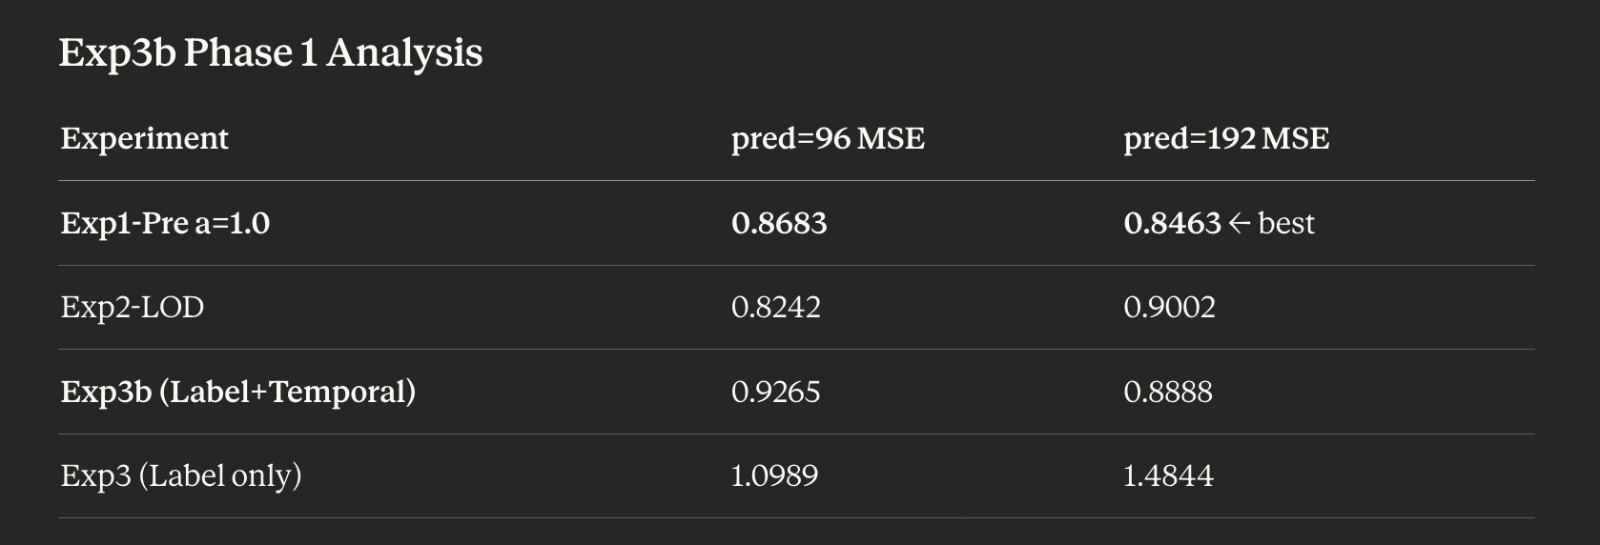

What This Tells You
Temporal embedding saved Legendre — partially. Restoring temporal brought MSE from 1.099 → 0.927 at pred=96 and from 1.484 → 0.889 at pred=192. That's a massive recovery, confirming Exp3's failure was entirely due to missing temporal, not Legendre itself.
But Legendre still doesn't beat Exp1-Pre. At both horizons Exp3b is worse than the simple pre-softmax decay. Legendre is not actively harmful when combined with temporal — it's just not better than what we already have.
Interesting pattern: Exp3b is better at pred=192 (0.889) than pred=96 (0.927). This is unusual — normally longer horizons are harder. It suggests Legendre orthogonality might be providing some useful long-range distinctiveness but not short-range.

In [9]:
!bash experiments/E-96-3b-Label-Temporal-Controlled/exp3b_phase2.sh

Experiment 3b — Phase 2: Label + Temporal (Controlled)
Formula   : X'_i = X_i + T_i + P_i
Value     : TokenEmbedding (semantic content)
Temporal  : TimeFeatureEmbedding (RESTORED)
Position  : Legendre polynomials (replaces sinusoidal PE)
No distance operator, no alpha, no ordering signal

Phase 1 note: pred=96  MSE=0.9265 vs Exp1-Pre 0.8683
              pred=192 MSE=0.8888 vs Exp1-Pre 0.8463
              Partial recovery vs Exp3 but below Exp1-Pre

Seeds     : 2021, 2022, 2023
Pred lens : 48, 96, 192, 336
Total runs: 12 (1 config × 3 seeds × 4 pred_lens)
Start: Sun Apr  5 01:08:24 PM UTC 2026

Copying experiment files...
Files copied successfully.

------------------------------------------------------------
RUN 1/12: exp3b_ph2_ETTh1_leg_temporal_pred48_seed2021
pred_len=48 | seed=2021 | config=legendre+temporal
Start: Sun Apr  5 01:08:24 PM UTC 2026
Args in experiment:
Namespace(model='informer', data='ETTh1', root_path='./data/ETT/', data_path='ETTh1.csv', features='M', target='OT'

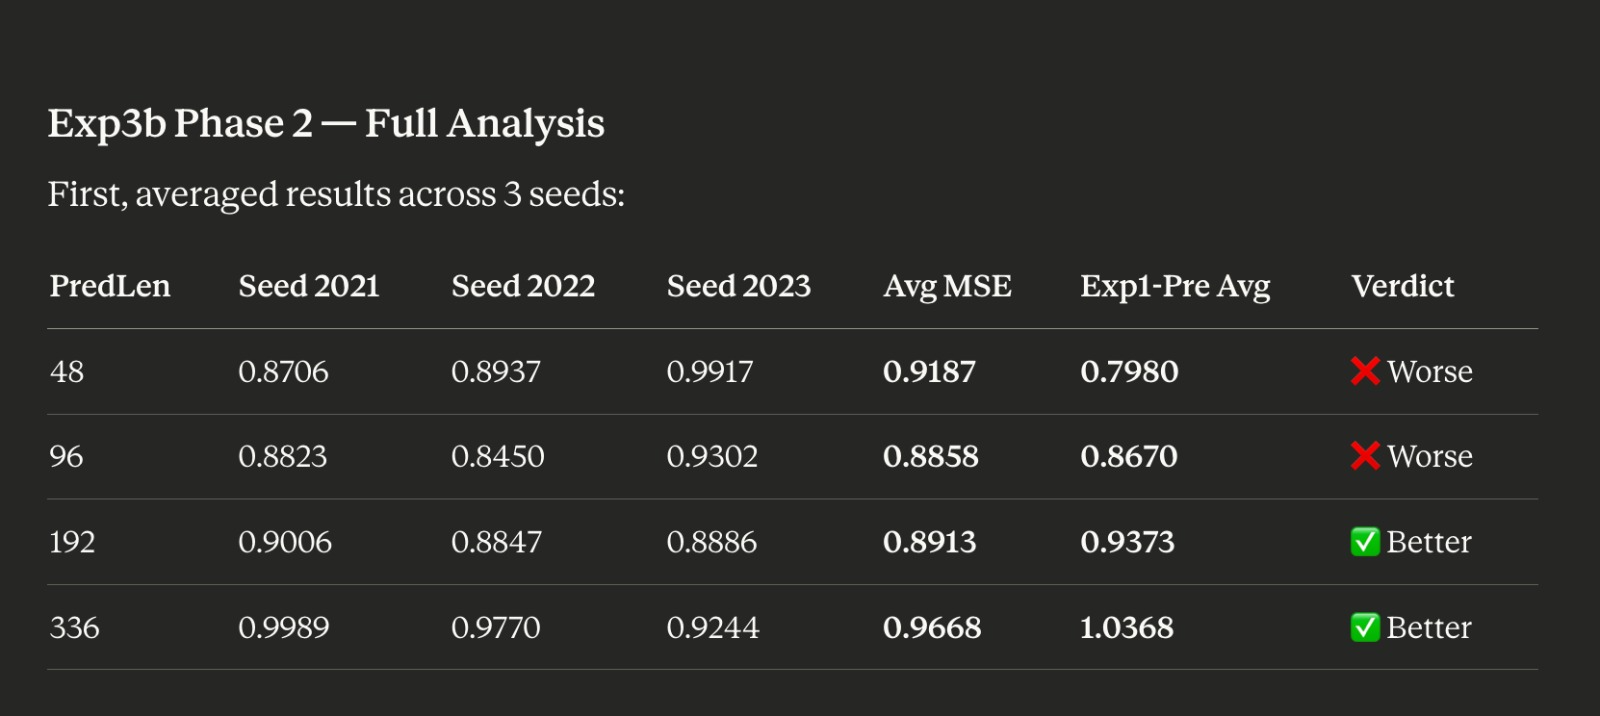

### What You Should Notice

Exp3b is worse at short horizons but better at long horizons. This is a clean, consistent finding — not noise.

At pred_len=48 and 96, Exp1-Pre beats Exp3b comfortably. At pred_len=192 and 336, Exp3b beats Exp1-Pre by meaningful margins (0.046 and 0.070 respectively).

The seed variance is also much better than Exp1-Pre at pred_len=336. Exp1-Pre had a spread of 0.29 (0.876 to 1.162) while Exp3b has a spread of only 0.075 (0.924 to 0.999) — Legendre embeddings appear to stabilise long-horizon training.

Why this makes theoretical sense: Legendre polynomials provide orthogonal position distinctiveness — each position gets a unique, mathematically distinct label. At long horizons where the model needs to track relationships across many time steps, this orthogonality helps. At short horizons, the simpler distance decay in Exp1-Pre is sufficient and adding Legendre introduces unnecessary complexity.

### Exp3b Conclusion to Document

Legendre + Temporal (Exp3b, formula X'_i = X_i + T_i + P_i) shows a horizon-dependent trade-off. It underperforms Exp1-Pre at short horizons (pred_len 48: avg MSE 0.919 vs 0.798; pred_len 96: avg MSE 0.886 vs 0.867) but outperforms it at longer horizons (pred_len 192: avg MSE 0.891 vs 0.937; pred_len 336: avg MSE 0.967 vs 1.037).

Additionally, seed variance at pred_len=336 is significantly reduced (0.075 vs 0.29), suggesting Legendre orthogonality stabilises long-range learning.

Exp3b is not universally better than Exp1-Pre but is the preferred configuration for long-horizon forecasting.